In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import json
import warnings
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

%load_ext autoreload
%autoreload 2

In [2]:
# 🔒 Anclaje determinista a raíz del proyecto
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

# ✅ Carga fusionada para recuperar display_config
base_path = PROJECT_ROOT / "config" / "base_config.json"
with open(base_path, 'r', encoding='utf-8') as f:
    base_cfg = json.load(f)

disp = base_cfg.get('display_config', {})
SEP = disp.get('separator_char', '=') * disp.get('separator_length', 70)
IND = disp.get('indent', '   ')
PREFIX = disp.get('prefix_dataset', '📦 ')
TITLE = disp.get('section_title', '✅ CELDA {n} - {module} EJECUTADO')

print(f"{TITLE.format(n=1, module='CONFIGURACIÓN')}")
print(SEP)
print(f"{IND}📁 PROJECT_ROOT: {PROJECT_ROOT}")
print(f"{IND}🎨 Separator: '{disp.get('separator_char')}' × {disp.get('separator_length')}")
print(SEP)

✅ CELDA 1 - CONFIGURACIÓN EJECUTADO
   📁 PROJECT_ROOT: /Users/anaaguirre/Documents/Cicatrices_invisibles
   🎨 Separator: '=' × 70


In [3]:
# ✅ Cargar tablas generadas por el ETL
MASTER_PATH = PROJECT_ROOT / "data" / "master" / "master_table.parquet"
CLUSTER_PATH = PROJECT_ROOT / "data" / "master" / "tabla_clustering.parquet"

master = pd.read_parquet(MASTER_PATH)
clustering = pd.read_parquet(CLUSTER_PATH)

print(f"{TITLE.format(n=2, module='CARGA DE DATOS')}")
print(SEP)
print(f"{IND}📊 master_table.parquet: {len(master):,} filas × {len(master.columns)} columnas")
print(f"{IND}📊 tabla_clustering.parquet: {len(clustering):,} filas × {len(clustering.columns)} columnas")
print(f"{IND}📅 Rango temporal: {master['anio_hecho'].min()} - {master['anio_hecho'].max()}")
print(f"{IND}🗺️  Municipios únicos: {master['cod_municipio'].nunique()}")
if 'departamento' in master.columns:
    print(f"{IND}🗂️  Departamentos: {master['departamento'].dropna().unique().tolist()}")
print(SEP)

✅ CELDA 2 - CARGA DE DATOS EJECUTADO
   📊 master_table.parquet: 1,432 filas × 31 columnas
   📊 tabla_clustering.parquet: 179 filas × 24 columnas
   📅 Rango temporal: 2018 - 2025
   🗺️  Municipios únicos: 179
   🗂️  Departamentos: ['CAUCA', 'CHOCO', 'NARIÑO', 'VALLE DEL CAUCA']


✅ CELDA 3 - ANÁLISIS UNIVARIADO EJECUTADO
   📈 ICV-GEN-F: Distribución descriptiva
   📦  Media: 14.18 | Mediana: 11.78 | Std: 10.50
   📦  Rango: 0.00 - 65.54
   📦  Outliers (IQR): 22 (1.5%)
   📦  Skewness: 1.12 | Kurtosis: 1.57


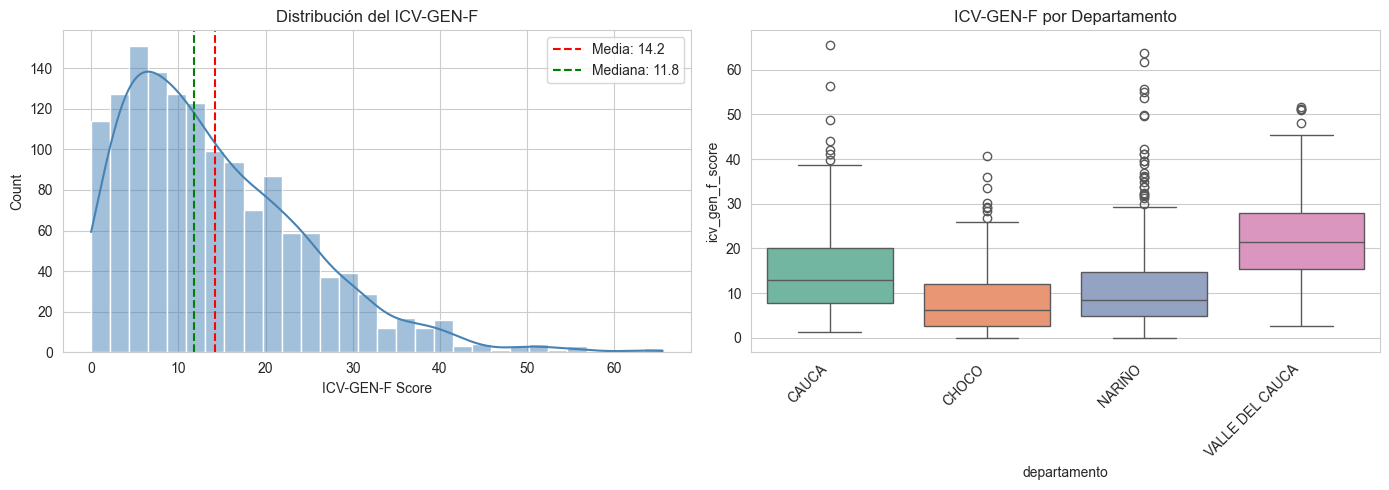


   ⚠️  Municipios outlier en ICV-GEN-F:
   📦 POPAYAN (CAUCA, 2018): 56.36
   📦 POPAYAN (CAUCA, 2019): 65.54
   📦 POPAYAN (CAUCA, 2020): 48.85
   📦 POPAYAN (CAUCA, 2022): 42.07
   📦 PIENDAMO  TUNIA (CAUCA, 2021): 44.15
   📦 PASTO (NARIÑO, 2018): 63.74
   📦 PASTO (NARIÑO, 2019): 61.75
   📦 PASTO (NARIÑO, 2021): 42.17
   📦 PASTO (NARIÑO, 2022): 55.71
   📦 PASTO (NARIÑO, 2023): 49.55


In [4]:
print(f"{TITLE.format(n=3, module='ANÁLISIS UNIVARIADO')}")
print(SEP)

# Métricas descriptivas del ICV
icv = master['icv_gen_f_score']
q1, q3 = icv.quantile([0.25, 0.75])
iqr = q3 - q1
outliers = icv[(icv < q1 - 1.5*iqr) | (icv > q3 + 1.5*iqr)]

print(f"{IND}📈 ICV-GEN-F: Distribución descriptiva")
print(f"{IND}{PREFIX} Media: {icv.mean():.2f} | Mediana: {icv.median():.2f} | Std: {icv.std():.2f}")
print(f"{IND}{PREFIX} Rango: {icv.min():.2f} - {icv.max():.2f}")
print(f"{IND}{PREFIX} Outliers (IQR): {len(outliers)} ({len(outliers)/len(icv)*100:.1f}%)")
print(f"{IND}{PREFIX} Skewness: {icv.skew():.2f} | Kurtosis: {icv.kurtosis():.2f}")

# Visualización: Histograma + Boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con densidad
sns.histplot(icv, bins=30, kde=True, ax=ax1, color='steelblue')
ax1.axvline(icv.mean(), color='red', linestyle='--', label=f'Media: {icv.mean():.1f}')
ax1.axvline(icv.median(), color='green', linestyle='--', label=f'Mediana: {icv.median():.1f}')
ax1.set_title('Distribución del ICV-GEN-F')
ax1.set_xlabel('ICV-GEN-F Score')
ax1.legend()

# Boxplot por departamento (si existe)
if 'departamento' in master.columns:
    sns.boxplot(data=master, x='departamento', y='icv_gen_f_score', ax=ax2, palette='Set2')
    ax2.set_title('ICV-GEN-F por Departamento')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
else:
    sns.boxplot(y=icv, ax=ax2, color='lightcoral')
    ax2.set_title('Boxplot del ICV-GEN-F')

plt.tight_layout()
plt.show()

# Detalle de outliers si los hay
if len(outliers) > 0:
    print(f"\n{IND}⚠️  Municipios outlier en ICV-GEN-F:")
    outlier_rows = master[master['icv_gen_f_score'].isin(outliers)][['cod_municipio', 'municipio', 'departamento', 'anio_hecho', 'icv_gen_f_score']].head(10)
    for _, row in outlier_rows.iterrows():
        print(f"{IND}{PREFIX}{row['municipio']} ({row['departamento']}, {row['anio_hecho']}): {row['icv_gen_f_score']:.2f}")

print(SEP)

In [5]:
# 🔍 EXTRACCIÓN DE DATOS — ANÁLISIS UNIVARIADO (Celda 4)
# Formato 100% estandarizado con TITLE, SEP, IND, PREFIX

print(f"{TITLE.format(n=4, module='EXTRACCIÓN DATOS UNIVARIADO')}")
print(SEP)

icv = master['icv_gen_f_score']
q1, q3 = icv.quantile([0.25, 0.75])
iqr = q3 - q1
outliers = icv[(icv < q1 - 1.5*iqr) | (icv > q3 + 1.5*iqr)]

# 📊 Sección 1: Métricas del Histograma
print(f"{IND}📊 DATOS DEL HISTOGRAMA (ICV-GEN-F distribución)")
print(f"{IND}{PREFIX} Media: {icv.mean():.2f} | Mediana: {icv.median():.2f} | Std: {icv.std():.2f}")
print(f"{IND}{PREFIX} Rango: {icv.min():.2f} - {icv.max():.2f}")
print(f"{IND}{PREFIX} Skewness: {icv.skew():.2f} | Kurtosis: {icv.kurtosis():.2f}")
print(f"{IND}{PREFIX} Outliers (IQR): {len(outliers)} ({len(outliers)/len(icv)*100:.1f}%)")

print(f"\n{IND}{PREFIX}🔍 Percentiles clave:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"{IND}{IND}{PREFIX} P{p}: {icv.quantile(p/100):.2f}")

# Outliers detallados
if len(outliers) > 0:
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    print(f"\n{IND}⚠️  Outliers (IQR method):")
    print(f"{IND}{PREFIX} Límites: [{lower:.2f}, {upper:.2f}]")
    print(f"{IND}{PREFIX} Valores extremos (top 10):")
    for val in outliers.nlargest(10):
        mun = master[master['icv_gen_f_score'] == val][['cod_municipio', 'municipio', 'departamento', 'anio_hecho']].iloc[0]
        print(f"{IND}{IND}{PREFIX} • {mun['municipio']} ({mun['departamento']}, {mun['anio_hecho']}): {val:.2f}")

# 📦 Sección 2: Datos del Boxplot por departamento
print(f"\n{IND}📦 DATOS DEL BOXPLOT (ICV-GEN-F por departamento)")
if 'departamento' in master.columns:
    dept_stats = master.groupby('departamento')['icv_gen_f_score'].agg([
        ('count', 'count'), ('mean', 'mean'), ('median', 'median'), ('std', 'std'),
        ('min', 'min'), ('max', 'max'), ('q25', lambda x: x.quantile(0.25)), ('q75', lambda x: x.quantile(0.75))
    ]).round(2).sort_values('mean', ascending=False)

    dept_stats['iqr'] = dept_stats['q75'] - dept_stats['q25']
    dept_stats['outlier_count'] = dept_stats.apply(
        lambda row: len(master[(master['departamento'] == row.name) &
                              ((master['icv_gen_f_score'] < row['q25'] - 1.5*row['iqr']) |
                               (master['icv_gen_f_score'] > row['q75'] + 1.5*row['iqr']))]),
        axis=1
    )

    # Imprimir tabla con formato
    for dept, row in dept_stats.iterrows():
        print(f"\n{IND}{PREFIX}🗂️  {dept.upper()}:")
        print(f"{IND}{IND}{PREFIX} n={int(row['count'])} | mean={row['mean']:.2f} | median={row['median']:.2f} | std={row['std']:.2f}")
        print(f"{IND}{IND}{PREFIX} rango=[{row['min']:.2f}, {row['max']:.2f}] | IQR={row['iqr']:.2f} | outliers={int(row['outlier_count'])}")

    # 🔍 Interpretación rápida estandarizada
    avg_regional = master['icv_gen_f_score'].mean()
    std_regional = master['icv_gen_f_score'].std()
    print(f"\n{IND}🎯 Interpretación rápida (vs promedio regional={avg_regional:.2f} ± {std_regional:.2f}):")
    for dept in dept_stats.index:
        mean_val = dept_stats.loc[dept, 'mean']
        if mean_val > avg_regional + std_regional:
            print(f"{IND}{PREFIX}🔴 {dept}: ICV={mean_val:.1f} → >1σ arriba. Candidato a intervención prioritaria.")
        elif mean_val < avg_regional - std_regional:
            print(f"{IND}{PREFIX}🟢 {dept}: ICV={mean_val:.1f} → >1σ abajo. Posible subregistro.")
        else:
            print(f"{IND}{PREFIX}🟡 {dept}: ICV={mean_val:.1f} → Dentro del rango esperado.")
else:
    print(f"{IND}{PREFIX}⚠️  Columna 'departamento' no encontrada. Boxplot general:")
    print(f"{IND}{IND}{PREFIX} Q1: {icv.quantile(0.25):.2f} | Mediana: {icv.median():.2f} | Q3: {icv.quantile(0.75):.2f}")
    print(f"{IND}{IND}{PREFIX} Bigotes: [{q1 - 1.5*iqr:.2f}, {q3 + 1.5*iqr:.2f}]")

print(SEP)
print(f"{IND}✅ Datos extraídos con formato estandarizado. Listo para pegar e interpretar.")

✅ CELDA 4 - EXTRACCIÓN DATOS UNIVARIADO EJECUTADO
   📊 DATOS DEL HISTOGRAMA (ICV-GEN-F distribución)
   📦  Media: 14.18 | Mediana: 11.78 | Std: 10.50
   📦  Rango: 0.00 - 65.54
   📦  Skewness: 1.12 | Kurtosis: 1.57
   📦  Outliers (IQR): 22 (1.5%)

   📦 🔍 Percentiles clave:
      📦  P10: 2.82
      📦  P25: 5.96
      📦  P50: 11.78
      📦  P75: 20.24
      📦  P90: 28.61
      📦  P95: 33.74
      📦  P99: 47.18

   ⚠️  Outliers (IQR method):
   📦  Límites: [-15.47, 41.67]
   📦  Valores extremos (top 10):
      📦  • POPAYAN (CAUCA, 2019): 65.54
      📦  • PASTO (NARIÑO, 2018): 63.74
      📦  • PASTO (NARIÑO, 2019): 61.75
      📦  • POPAYAN (CAUCA, 2018): 56.36
      📦  • PASTO (NARIÑO, 2022): 55.71
      📦  • PASTO (NARIÑO, 2024): 55.13
      📦  • PASTO (NARIÑO, 2025): 53.65
      📦  • ZARZAL (VALLE DEL CAUCA, 2019): 51.57
      📦  • ARGELIA (VALLE DEL CAUCA, 2021): 51.33
      📦  • ULLOA (VALLE DEL CAUCA, 2021): 51.21

   📦 DATOS DEL BOXPLOT (ICV-GEN-F por departamento)

   📦 🗂️  VALLE DEL

✅ CELDA 5 - ANÁLISIS BIVARIADO EJECUTADO
   🔗 Correlación de Spearman con icv_gen_f_score:
   📦 tasa_vif_adultas_f: 0.804 (🔴 Fuerte)
   📦 tasa_sexual_nna_f: 0.775 (🔴 Fuerte)
   📦 tasa_vif_nna_f: 0.672 (🟡 Moderada)
   📦 tasa_sexual_adultas_f: 0.572 (🟡 Moderada)


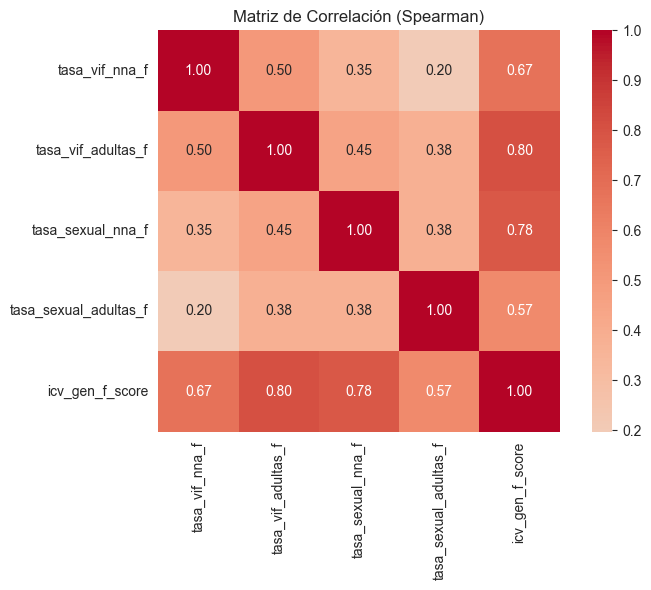

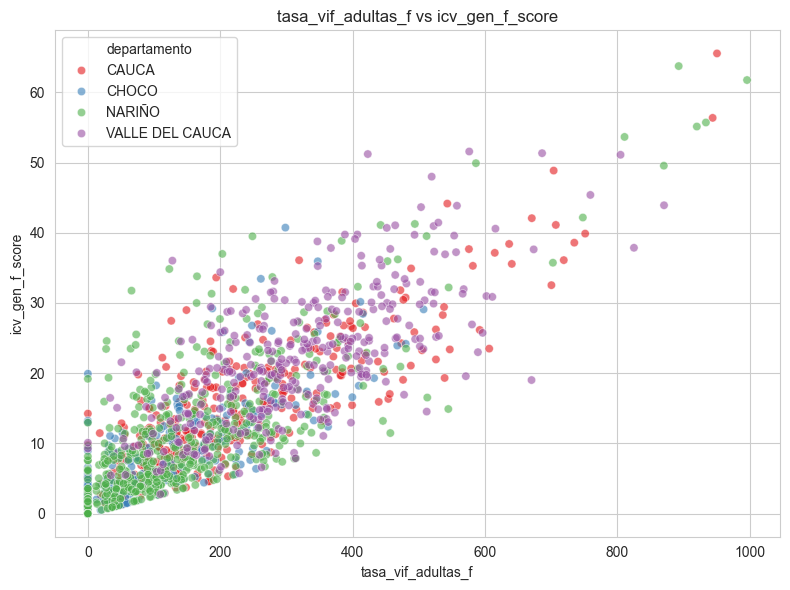

   📊 tasa_vif_adultas_f explica ~64.7% de la varianza del icv_gen_f_score


In [6]:
print(f"{TITLE.format(n=5, module='ANÁLISIS BIVARIADO')}")
print(SEP)

# ✅ Detección dinámica de columnas (cero hardcoding)
rate_cols = [c for c in master.columns if c.startswith('tasa_') and c.endswith('_f')]
target_col = 'icv_gen_f_score'
available_cols = [c for c in rate_cols + [target_col] if c in master.columns]

if len(available_cols) >= 2:
    # Matriz de correlación (Spearman para robustez)
    corr_matrix = master[available_cols].corr(method='spearman')
    corr_with_target = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)

    print(f"{IND}🔗 Correlación de Spearman con {target_col}:")
    for col, val in corr_with_target.items():
        strength = "🔴 Fuerte" if abs(val) > 0.7 else "🟡 Moderada" if abs(val) > 0.4 else "🟢 Débil"
        print(f"{IND}{PREFIX}{col}: {val:.3f} ({strength})")

    # Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
    plt.title('Matriz de Correlación (Spearman)')
    plt.tight_layout()
    plt.show()

    # Scatterplot: variable más correlacionada
    top_corr = corr_with_target.idxmax()
    if top_corr:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=master, x=top_corr, y=target_col,
            alpha=0.6, hue='departamento' if 'departamento' in master.columns else None,
            palette='Set1'
        )
        plt.title(f'{top_corr} vs {target_col}')
        plt.xlabel(top_corr)
        plt.ylabel(target_col)
        plt.tight_layout()
        plt.show()
        print(f"{IND}📊 {top_corr} explica ~{corr_with_target.max()**2*100:.1f}% de la varianza del {target_col}")
else:
    print(f"{IND}⚠️  No hay columnas de tasas femeninas disponibles para correlación.")

print(SEP)

In [7]:
# 🔍 EXTRACCIÓN DE DATOS — ANÁLISIS BIVARIADO (Celda 5)
# Formato estandarizado + datos para interpretación

print(f"{TITLE.format(n=6, module='EXTRACCIÓN DATOS BIVARIADO')}")
print(SEP)

rate_cols = [c for c in master.columns if c.startswith('tasa_') and c.endswith('_f')]
target_col = 'icv_gen_f_score'
available_cols = [c for c in rate_cols + [target_col] if c in master.columns]

if len(available_cols) >= 2:
    corr_matrix = master[available_cols].corr(method='spearman')
    corr_with_target = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)

    print(f"{IND}🔗 Correlación de Spearman con {target_col}:")
    for col, val in corr_with_target.items():
        strength = "🔴 Fuerte (>|0.7|)" if abs(val) > 0.7 else "🟡 Moderada (>|0.4|)" if abs(val) > 0.4 else "🟢 Débil"
        print(f"{IND}{PREFIX}{col}: {val:.3f} ({strength})")

    top_corr = corr_with_target.idxmax()
    top_val = corr_with_target.max()
    print(f"\n{IND}🎯 Lectura estratégica:")
    if top_val > 0.85:
        print(f"{IND}{PREFIX}✅ {top_corr} explica ~{top_val**2*100:.1f}% de la varianza del ICV.")
        print(f"{IND}{PREFIX}→ El índice está fuertemente impulsado por una sola tasa.")
    elif top_val > 0.6:
        print(f"{IND}{PREFIX}✅ Correlación sólida y balanceada. El ICV captura múltiples dimensiones.")
    else:
        print(f"{IND}{PREFIX}⚠️ Correlaciones débiles. Revisar pesos o añadir features contextuales.")

    print(f"\n{IND}📦 Features para K-Means (|r| > 0.3):")
    for i, (col, val) in enumerate(corr_with_target.items(), 1):
        if abs(val) > 0.3:
            print(f"{IND}{PREFIX}{i}. {col} (r={val:.3f})")
else:
    print(f"{IND}⚠️ No hay columnas de tasas femeninas disponibles.")

print(SEP)

✅ CELDA 6 - EXTRACCIÓN DATOS BIVARIADO EJECUTADO
   🔗 Correlación de Spearman con icv_gen_f_score:
   📦 tasa_vif_adultas_f: 0.804 (🔴 Fuerte (>|0.7|))
   📦 tasa_sexual_nna_f: 0.775 (🔴 Fuerte (>|0.7|))
   📦 tasa_vif_nna_f: 0.672 (🟡 Moderada (>|0.4|))
   📦 tasa_sexual_adultas_f: 0.572 (🟡 Moderada (>|0.4|))

   🎯 Lectura estratégica:
   📦 ✅ Correlación sólida y balanceada. El ICV captura múltiples dimensiones.

   📦 Features para K-Means (|r| > 0.3):
   📦 1. tasa_vif_adultas_f (r=0.804)
   📦 2. tasa_sexual_nna_f (r=0.775)
   📦 3. tasa_vif_nna_f (r=0.672)
   📦 4. tasa_sexual_adultas_f (r=0.572)


✅ CELDA 7 - ANÁLISIS TEMPORAL EJECUTADO
   📅 Tendencia del ICV-GEN-F por año:
                mean    std  count  min    max
   anio_hecho                                 
   2018        14.53  10.99    179  0.0  63.74
   2019        14.71   11.3    179  0.0  65.54
   2020        13.68  10.02    179  0.0  48.85
   2021        15.87  11.64    179  0.0  51.33
   2022         13.0   9.78    179  0.0  55.71
   2023        13.35   9.06    179  0.0  49.55
   2024        14.62  10.61    179  0.0  55.13
   2025        13.68  10.31    179  0.0  53.65


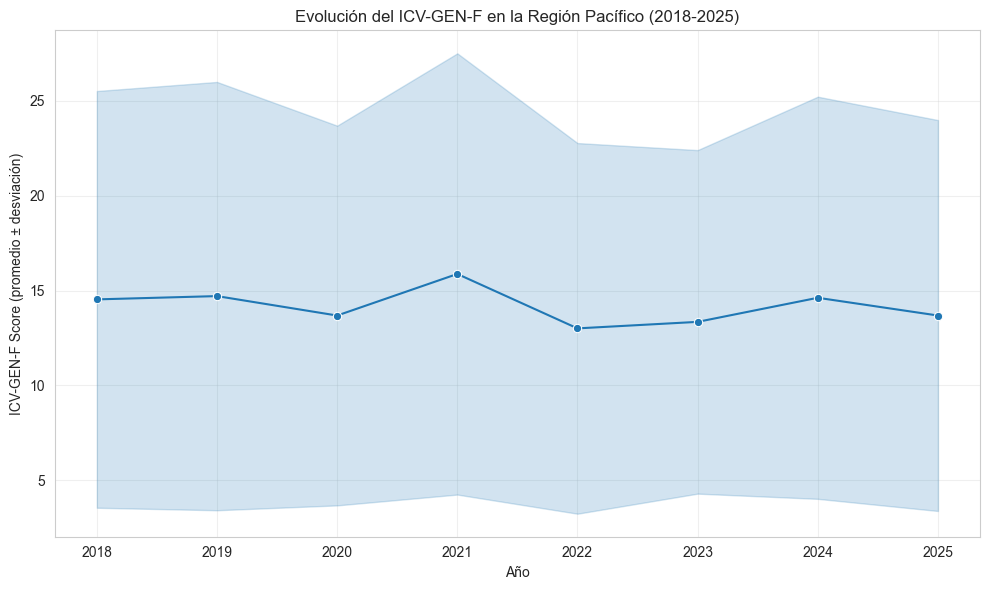

   📊 Regresión lineal: pendiente=-0.122, R²=0.104, 📉 Descendente, ⚠️ No significativa (p≥0.05)

   🗺️  Tendencia por departamento:


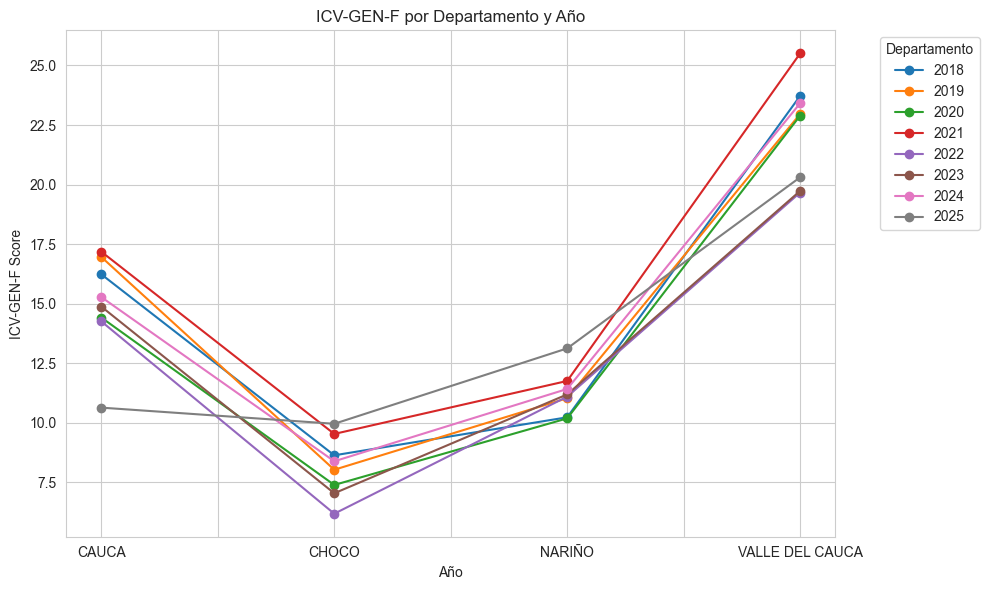

In [8]:
print(f"{TITLE.format(n=7, module='ANÁLISIS TEMPORAL')}")
print(SEP)

# Agregación temporal del ICV
trend = master.groupby('anio_hecho')['icv_gen_f_score'].agg(['mean', 'std', 'count', 'min', 'max']).round(2)
print(f"{IND}📅 Tendencia del ICV-GEN-F por año:")
print(f"{IND}{trend.to_string().replace(chr(10), chr(10)+IND)}")

# Visualización: Serie temporal con banda de confianza
plt.figure(figsize=(10, 6))
sns.lineplot(data=master, x='anio_hecho', y='icv_gen_f_score', estimator='mean', errorbar='sd', marker='o')
plt.title('Evolución del ICV-GEN-F en la Región Pacífico (2018-2025)')
plt.xlabel('Año')
plt.ylabel('ICV-GEN-F Score (promedio ± desviación)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test de tendencia (Mann-Kendall simplificado)
years = master['anio_hecho'].unique()
if len(years) >= 4:
    annual_means = master.groupby('anio_hecho')['icv_gen_f_score'].mean()
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, annual_means)
    direction = "📈 Ascendente" if slope > 0 else "📉 Descendente" if slope < 0 else "➡️ Estable"
    significance = "✅ Significativa (p<0.05)" if p_value < 0.05 else "⚠️ No significativa (p≥0.05)"
    print(f"{IND}📊 Regresión lineal: pendiente={slope:.3f}, R²={r_value**2:.3f}, {direction}, {significance}")

# Tendencia por departamento (si existe)
if 'departamento' in master.columns:
    print(f"\n{IND}🗺️  Tendencia por departamento:")
    dept_trend = master.groupby(['departamento', 'anio_hecho'])['icv_gen_f_score'].mean().unstack()
    dept_trend.plot(marker='o', figsize=(10, 6), title='ICV-GEN-F por Departamento y Año')
    plt.xlabel('Año')
    plt.ylabel('ICV-GEN-F Score')
    plt.legend(title='Departamento', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print(SEP)

In [9]:
# 🔍 EXTRACCIÓN DE DATOS — ANÁLISIS TEMPORAL (Celda 6)
# Formato estandarizado + datos para interpretación

print(f"{TITLE.format(n=8, module='EXTRACCIÓN DATOS TEMPORAL')}")
print(SEP)

# Agregación temporal del ICV
trend = master.groupby('anio_hecho')['icv_gen_f_score'].agg(['mean', 'std', 'count', 'min', 'max']).round(2)
print(f"{IND}📅 Evolución del ICV-GEN-F por año:")
for year, row in trend.iterrows():
    print(f"{IND}{PREFIX}{year}: mean={row['mean']:.2f} ± {row['std']:.2f} | n={int(row['count'])} | rango=[{row['min']:.2f}, {row['max']:.2f}]")

# Regresión lineal para tendencia
from scipy import stats
years = master['anio_hecho'].unique()
if len(years) >= 4:
    annual_means = master.groupby('anio_hecho')['icv_gen_f_score'].mean()
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, annual_means)
    direction = "📈 Ascendente" if slope > 0 else "📉 Descendente" if slope < 0 else "➡️ Estable"
    significance = "✅ Significativa (p<0.05)" if p_value < 0.05 else "⚠️ No significativa (p≥0.05)"

    print(f"\n{IND}📊 Regresión lineal:")
    print(f"{IND}{PREFIX}Pendiente: {slope:.3f} | R²: {r_value**2:.3f} | {direction} | {significance}")

    # Lectura estratégica
    print(f"\n{IND}🎯 Interpretación estratégica:")
    if slope > 0.2 and p_value < 0.05:
        print(f"{IND}{PREFIX}🔴 Tendencia ascendente significativa → Narrativa de urgencia: la violencia está empeorando.")
    elif slope < -0.2 and p_value < 0.05:
        print(f"{IND}{PREFIX}🟢 Tendencia descendente significativa → Posible impacto de intervenciones.")
    else:
        print(f"{IND}{PREFIX}🟡 Estancamiento o cambio no significativo → La violencia se normaliza, no se resuelve.")

# Tendencia por departamento (si existe)
if 'departamento' in master.columns:
    print(f"\n{IND}🗺️ Tendencia por departamento (pendiente anual):")
    for dept in master['departamento'].dropna().unique():
        dept_data = master[master['departamento'] == dept]
        if len(dept_data['anio_hecho'].unique()) >= 4:
            dept_means = dept_data.groupby('anio_hecho')['icv_gen_f_score'].mean()
            d_slope, _, d_r, d_p, _ = stats.linregress(dept_means.index, dept_means.values)
            marker = "📈" if d_slope > 0.1 else "📉" if d_slope < -0.1 else "➡️"
            sig = "✅" if d_p < 0.05 else "⚠️"
            print(f"{IND}{PREFIX}{marker} {sig} {dept}: slope={d_slope:.3f} (p={d_p:.3f})")

print(SEP)

✅ CELDA 8 - EXTRACCIÓN DATOS TEMPORAL EJECUTADO
   📅 Evolución del ICV-GEN-F por año:
   📦 2018: mean=14.53 ± 10.99 | n=179 | rango=[0.00, 63.74]
   📦 2019: mean=14.71 ± 11.30 | n=179 | rango=[0.00, 65.54]
   📦 2020: mean=13.68 ± 10.02 | n=179 | rango=[0.00, 48.85]
   📦 2021: mean=15.87 ± 11.64 | n=179 | rango=[0.00, 51.33]
   📦 2022: mean=13.00 ± 9.78 | n=179 | rango=[0.00, 55.71]
   📦 2023: mean=13.35 ± 9.06 | n=179 | rango=[0.00, 49.55]
   📦 2024: mean=14.62 ± 10.61 | n=179 | rango=[0.00, 55.13]
   📦 2025: mean=13.68 ± 10.31 | n=179 | rango=[0.00, 53.65]

   📊 Regresión lineal:
   📦 Pendiente: -0.122 | R²: 0.104 | 📉 Descendente | ⚠️ No significativa (p≥0.05)

   🎯 Interpretación estratégica:
   📦 🟡 Estancamiento o cambio no significativo → La violencia se normaliza, no se resuelve.

   🗺️ Tendencia por departamento (pendiente anual):
   📦 📉 ⚠️ CAUCA: slope=-0.585 (p=0.058)
   📦 ➡️ ⚠️ CHOCO: slope=0.079 (p=0.717)
   📦 📈 ✅ NARIÑO: slope=0.292 (p=0.025)
   📦 📉 ⚠️ VALLE DEL CAUCA: slope

✅ CELDA 9 - ANÁLISIS ESPACIAL EJECUTADO
   🗺️  ICV-GEN-F promedio por departamento:
                     mean   std  count
   departamento                       
   VALLE DEL CAUCA  22.28  9.28    336
   CAUCA            14.98  9.66    336
   NARIÑO           11.26  9.75    512
   CHOCO             8.15  7.42    248


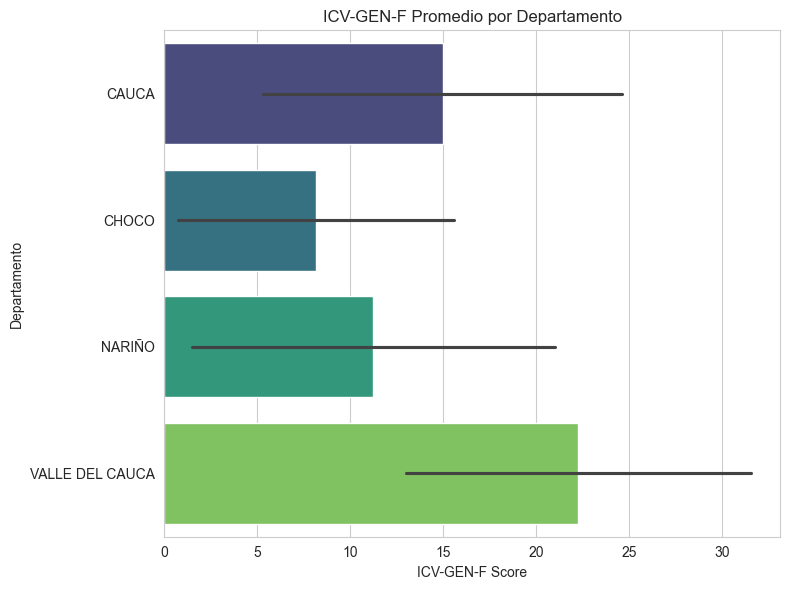

   🗺️  Mapa interactivo: requiere geojson de municipios. Datos listos en 'mun_map'.


In [10]:
print(f"{TITLE.format(n=9, module='ANÁLISIS ESPACIAL')}")
print(SEP)

if 'departamento' in master.columns:
    # Resumen por departamento
    dept_summary = master.groupby('departamento')['icv_gen_f_score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False).round(2)
    print(f"{IND}🗺️  ICV-GEN-F promedio por departamento:")
    print(f"{IND}{dept_summary.to_string().replace(chr(10), chr(10)+IND)}")

    # Gráfico de barras
    plt.figure(figsize=(8, 6))
    sns.barplot(data=master, x='icv_gen_f_score', y='departamento', estimator='mean', errorbar='sd', palette='viridis')
    plt.title('ICV-GEN-F Promedio por Departamento')
    plt.xlabel('ICV-GEN-F Score')
    plt.ylabel('Departamento')
    plt.tight_layout()
    plt.show()

    # Mapa coroplético interactivo (si hay coordenadas o se puede mapear)
    # Nota: Para un mapa real necesitarías un geojson de municipios.
    # Aquí mostramos una alternativa con plotly si tienes columna 'lat'/'lon' o usas nombres.
    if all(col in master.columns for col in ['municipio', 'anio_hecho']):
        # Promedio por municipio para el mapa
        mun_map = master.groupby('municipio')['icv_gen_f_score'].mean().reset_index()
        fig = px.choropleth(
            mun_map,
            locations='municipio',
            locationmode='country names',  # Cambiar a 'geojson' si tienes shapefile
            color='icv_gen_f_score',
            title='ICV-GEN-F Promedio por Municipio (2018-2025)',
            color_continuous_scale='Reds'
        )
        # fig.show()  # Descomentar si tienes configuración de mapbox o geojson
        print(f"{IND}🗺️  Mapa interactivo: requiere geojson de municipios. Datos listos en 'mun_map'.")
else:
    print(f"{IND}⚠️  Columna 'departamento' no encontrada. Análisis espacial limitado.")

print(SEP)

In [11]:
# 🔍 EXTRACCIÓN DE DATOS — ANÁLISIS ESPACIAL (Celda 7)
# Formato estandarizado + datos para interpretación

print(f"{TITLE.format(n=10, module='EXTRACCIÓN DATOS ESPACIAL')}")
print(SEP)

if 'departamento' in master.columns:
    dept_summary = master.groupby('departamento')['icv_gen_f_score'].agg([
        ('count', 'count'), ('mean', 'mean'), ('median', 'median'), ('std', 'std'),
        ('min', 'min'), ('max', 'max'), ('p90', lambda x: x.quantile(0.90))
    ]).round(2).sort_values('mean', ascending=False)

    print(f"{IND}🗺️ ICV-GEN-F por departamento:")
    for dept, row in dept_summary.iterrows():
        print(f"{IND}{PREFIX}{dept}: n={int(row['count'])} | mean={row['mean']:.2f} | median={row['median']:.2f} | p90={row['p90']:.2f} | max={row['max']:.2f}")

    # Comparación regional
    avg_regional = master['icv_gen_f_score'].mean()
    std_regional = master['icv_gen_f_score'].std()
    print(f"\n{IND}🎯 Comparación vs promedio regional ({avg_regional:.2f} ± {std_regional:.2f}):")
    for dept in dept_summary.index:
        mean_val = dept_summary.loc[dept, 'mean']
        diff_sigma = (mean_val - avg_regional) / std_regional
        if diff_sigma > 1:
            print(f"{IND}{PREFIX}🔴 {dept}: +{diff_sigma:.2f}σ → Candidato a intervención prioritaria.")
        elif diff_sigma < -1:
            print(f"{IND}{PREFIX}🟢 {dept}: {diff_sigma:.2f}σ → Posible subregistro o menor exposición.")
        else:
            print(f"{IND}{PREFIX}🟡 {dept}: {diff_sigma:+.2f}σ → Dentro del rango esperado.")

    # Top municipios por ICV (para priorización)
    print(f"\n{IND}🏆 Top 10 municipios por ICV promedio (2018-2025):")
    top_mun = master.groupby(['cod_municipio', 'municipio', 'departamento'])['icv_gen_f_score'].mean().reset_index()
    top_mun = top_mun.sort_values('icv_gen_f_score', ascending=False).head(10)
    for _, row in top_mun.iterrows():
        print(f"{IND}{PREFIX}• {row['municipio']} ({row['departamento']}): {row['icv_gen_f_score']:.2f}")
else:
    print(f"{IND}⚠️ Columna 'departamento' no encontrada. Análisis espacial limitado.")

print(SEP)

✅ CELDA 10 - EXTRACCIÓN DATOS ESPACIAL EJECUTADO
   🗺️ ICV-GEN-F por departamento:
   📦 VALLE DEL CAUCA: n=336 | mean=22.28 | median=21.43 | p90=34.19 | max=51.57
   📦 CAUCA: n=336 | mean=14.98 | median=13.00 | p90=27.07 | max=65.54
   📦 NARIÑO: n=512 | mean=11.26 | median=8.42 | p90=23.07 | max=63.74
   📦 CHOCO: n=248 | mean=8.15 | median=6.24 | p90=16.71 | max=40.73

   🎯 Comparación vs promedio regional (14.18 ± 10.50):
   📦 🟡 VALLE DEL CAUCA: +0.77σ → Dentro del rango esperado.
   📦 🟡 CAUCA: +0.08σ → Dentro del rango esperado.
   📦 🟡 NARIÑO: -0.28σ → Dentro del rango esperado.
   📦 🟡 CHOCO: -0.57σ → Dentro del rango esperado.

   🏆 Top 10 municipios por ICV promedio (2018-2025):
   📦 • PASTO (NARIÑO): 52.18
   📦 • POPAYAN (CAUCA): 45.85
   📦 • YUMBO (VALLE DEL CAUCA): 34.64
   📦 • RESTREPO (VALLE DEL CAUCA): 31.80
   📦 • CANDELARIA (VALLE DEL CAUCA): 31.63
   📦 • CALI (VALLE DEL CAUCA): 30.27
   📦 • PIENDAMO  TUNIA (CAUCA): 29.75
   📦 • ROLDANILLO (VALLE DEL CAUCA): 28.80
   📦 • RI